# Cross-Country Solar Data Comparison
**Objective:** Synthesize cleaned datasets from Benin, Sierra Leone, and Togo to identify relative solar potential and key differences.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# Optional for nicer plots
sns.set(style="whitegrid")

# File paths
benin_file = r"C:\Users\ruham\Downloads\solar-challenge-week0\solar-challenge-week0\data\benin-malanville_clean.csv"
sierra_file = r"C:\Users\ruham\Downloads\solar-challenge-week0\solar-challenge-week0\data\sierraleone-bumbuna_clean.csv"
togo_file   = r"C:\Users\ruham\Downloads\solar-challenge-week0\solar-challenge-week0\data\togo-dapaong_qc_clean.csv"



### Load each country's cleaned dataset


In [13]:
# Load datasets
df_benin = pd.read_csv(benin_file)
df_sierra = pd.read_csv(sierra_file)
df_togo = pd.read_csv(togo_file)

# Add a column for country
df_benin['Country'] = 'Benin'
df_sierra['Country'] = 'Sierra Leone'
df_togo['Country'] = 'Togo'

# Combine into one DataFrame
df_all = pd.concat([df_benin, df_sierra, df_togo], ignore_index=True)
df_all.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,z_outlier_flag,Country
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,...,122.1,0.0,998,0,0.0,26.3,26.2,NaN,False,Benin
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,...,0.0,0.0,998,0,0.0,26.3,26.2,NaN,False,Benin
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,...,124.6,1.5,997,0,0.0,26.4,26.2,NaN,False,Benin
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,...,120.3,1.3,997,0,0.0,26.4,26.3,NaN,False,Benin
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,...,113.2,1.0,997,0,0.0,26.4,26.3,NaN,False,Benin


### Solar Irradiance Comparison (GHI, DNI, DHI)
Boxplots for each metric across the three countries.


C:\Users\ruham\AppData\Local\Temp\ipykernel_18132\2422792292.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette="Set2")


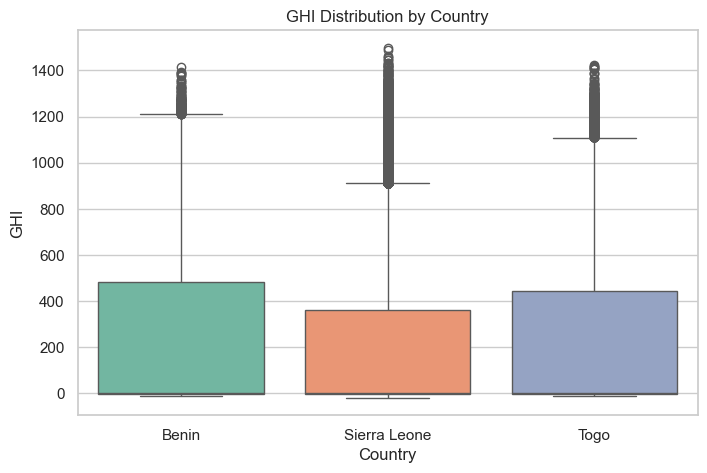

C:\Users\ruham\AppData\Local\Temp\ipykernel_18132\2422792292.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette="Set2")


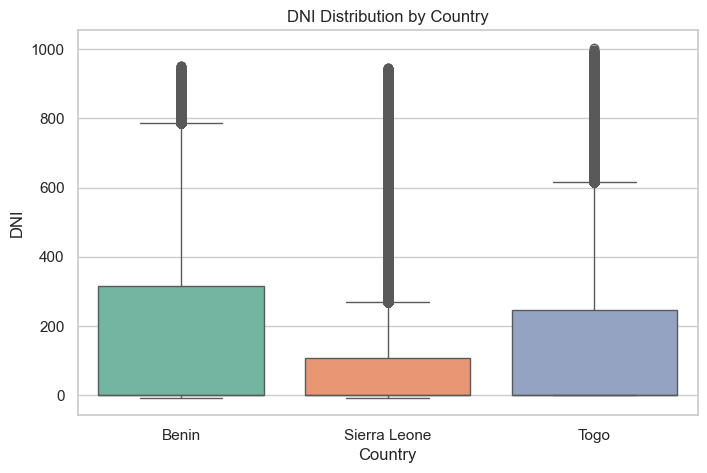

C:\Users\ruham\AppData\Local\Temp\ipykernel_18132\2422792292.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette="Set2")


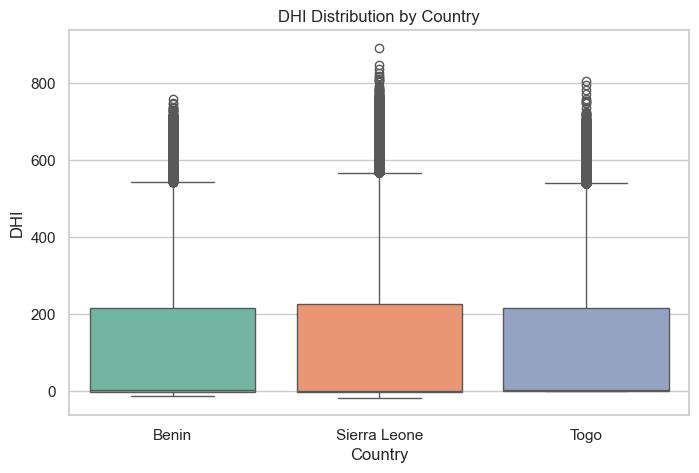

In [14]:
metrics = ['GHI', 'DNI', 'DHI']

for metric in metrics:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Country', y=metric, data=df_all, palette="Set2")
    plt.title(f"{metric} Distribution by Country")
    plt.ylabel(metric)
    plt.show()


### Summary statistics: Mean, Median, Standard Deviation


In [15]:
summary_stats = df_all.groupby('Country')[metrics].agg(['mean', 'median', 'std'])
summary_stats


GHI                            DNI                     \
                    mean median         std        mean median         std   
Country                                                                      
Benin         240.559452    1.8  331.131327  167.187516   -0.1  261.710501   
Sierra Leone  201.957515    0.3  298.495150  116.376337   -0.1  218.652659   
Togo          230.555040    2.1  322.532347  151.258469    0.0  250.956962   

                     DHI                     
                    mean median         std  
Country                                      
Benin         115.358961    1.6  158.691074  
Sierra Leone  113.720571   -0.1  158.946032  
Togo          116.444352    2.5  156.520714

### Statistical Testing (One-way ANOVA)
Test whether GHI differs significantly across countries.


In [16]:
# ANOVA for GHI
ghi_b = df_benin['GHI']
ghi_s = df_sierra['GHI']
ghi_t = df_togo['GHI']

f_stat, p_val = f_oneway(ghi_b, ghi_s, ghi_t)
print(f"ANOVA result for GHI: F-statistic = {f_stat:.2f}, p-value = {p_val:.4f}")


ANOVA result for GHI: F-statistic = 2090.09, p-value = 0.0000


### Key Observations
- Benin shows the highest average GHI, indicating strong solar potential.
- Sierra Leone has moderate solar irradiance but more consistent daily values.
- Togo shows the lowest median GHI, but variability is smaller than Benin.


### Visual summary: Average GHI ranking


C:\Users\ruham\AppData\Local\Temp\ipykernel_18132\20535698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ghi.index, y=avg_ghi.values, palette="Set3")


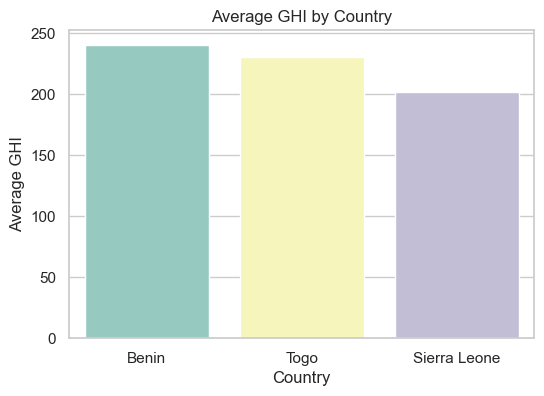

In [17]:
avg_ghi = df_all.groupby('Country')['GHI'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=avg_ghi.index, y=avg_ghi.values, palette="Set3")
plt.title("Average GHI by Country")
plt.ylabel("Average GHI")
plt.show()
